In [35]:
import yfinance as yf
import matplotlib.pyplot as plt

In [36]:
df = yf.download('TSLA',start='2020-11-01')

[*********************100%***********************]  1 of 1 completed


In [37]:
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-11-02,133.503326,135.660004,130.766663,131.333328,87063300
2020-11-03,141.300003,142.589996,135.563339,136.576660,103055100
2020-11-04,140.326660,145.133331,139.033340,143.539993,96429300
2020-11-05,146.029999,146.666672,141.333328,142.766663,85243500
2020-11-06,143.316666,145.523331,141.426666,145.366669,65118000
...,...,...,...,...,...
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800


In [38]:
def MACD(df):
    df['EMA12'] = df.Close.ewm(span=12).mean()
    df['EMA26'] = df.Close.ewm(span=26).mean()
    df['MACD'] = df.EMA12 - df.EMA26
    df['Signal'] = df.MACD.ewm(span=9).mean()
    print('Indicator added')

In [39]:
MACD(df)

Indicator added


In [40]:
df

Price,Close,High,Low,Open,Volume,EMA12,EMA26,MACD,Signal
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,
Date,,,,,,,,,
2020-11-02,133.503326,135.660004,130.766663,131.333328,87063300,133.503326,133.503326,0.000000,0.000000
2020-11-03,141.300003,142.589996,135.563339,136.576660,103055100,137.726526,137.551601,0.174925,0.097181
2020-11-04,140.326660,145.133331,139.033340,143.539993,96429300,138.741359,138.548653,0.192706,0.136331
2020-11-05,146.029999,146.666672,141.333328,142.766663,85243500,141.042098,140.640110,0.401988,0.226323
2020-11-06,143.316666,145.523331,141.426666,145.366669,65118000,141.660090,141.260814,0.399275,0.277772
...,...,...,...,...,...,...,...,...,...
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900,404.188149,410.525107,-6.336958,-7.110828
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800,402.776127,409.375840,-6.599713,-7.008605


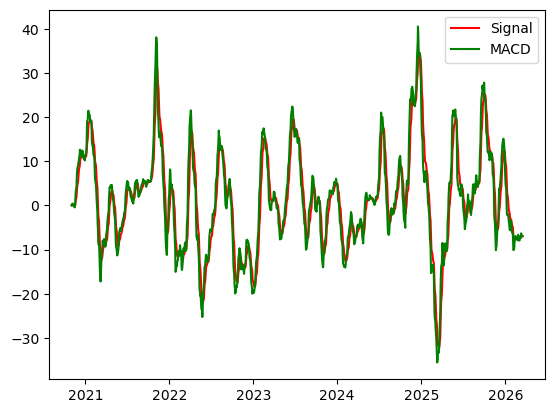

In [41]:
plt.plot(df.Signal, label='Signal', color='red')
plt.plot(df.MACD, label="MACD", color='green')
plt.legend()
plt.show()

In [42]:
Buy, Sell = [], []

for i in range(2, len(df)):
    if df.MACD.iloc[i] > df.Signal.iloc[i] and df.MACD.iloc[i - 1] < df.Signal.iloc[i - 1]:
        Buy.append(i)
    elif df.MACD.iloc[i] < df.Signal.iloc[i] and df.MACD.iloc[i - 1] > df.Signal.iloc[i - 1]:
        Sell.append(i)

In [43]:
Buy

[11,
 41,
 89,
 102,
 141,
 172,
 186,
 207,
 226,
 234,
 237,
 289,
 301,
 319,
 324,
 333,
 344,
 395,
 448,
 467,
 498,
 520,
 549,
 600,
 630,
 670,
 707,
 735,
 757,
 784,
 821,
 850,
 874,
 909,
 953,
 962,
 1000,
 1030,
 1099,
 1113,
 1122,
 1164,
 1179,
 1195,
 1206,
 1215,
 1256,
 1274,
 1324,
 1333,
 1339,
 1342,
 1346]

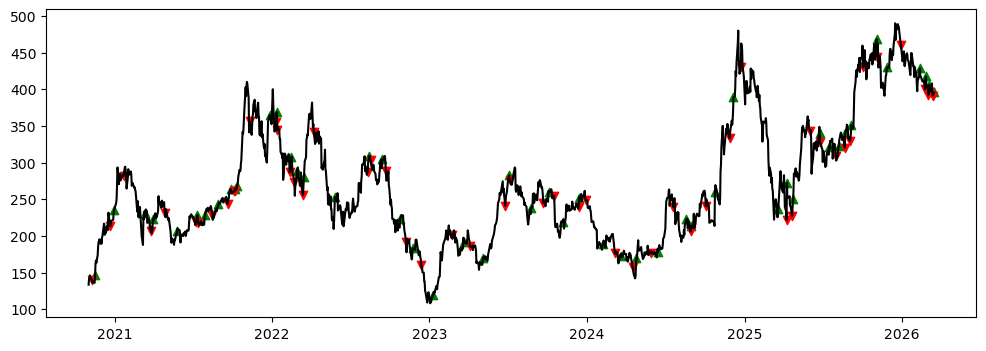

In [44]:
plt.figure(figsize=(12,4))
plt.scatter(df.iloc[Buy].index, df.iloc[Buy].Close, marker ='^', color='green') #this code gives the dates where buy signal was generated
plt.scatter(df.iloc[Sell].index, df.iloc[Sell].Close, marker = 'v', color='red') #this code gives the dates where sell signal was generated
plt.plot(df.Close, label='Close price', color='k')
plt.show()

In [45]:
Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

In [46]:
Buyprices = df.Open.iloc[Realbuys]
Sellprices = df.Open.iloc[Realsells]


In [47]:
Buyprices

Ticker,TSLA
Date,
2020-11-18,149.449997
2021-01-04,239.820007
2021-03-15,231.363327
2021-04-01,229.456665
2021-05-27,206.746674
2021-07-13,228.773331
2021-08-02,233.333328
2021-08-31,244.333328
2021-09-28,262.399994


In [48]:
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])
elif Buyprices.index[0] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Buyprices.index[-1])

# Removing the first sell signal and the last buy signal

In [49]:
profitsrel = []

for i in range(len(Sellprices)):
    profitsrel.append((Sellprices.iloc[i] - Buyprices.iloc[i])/Buyprices.iloc[i])
    

In [51]:
sum(profitsrel)/len(profitsrel)

Ticker
TSLA    0.05032
dtype: float64